<a href="https://colab.research.google.com/github/Saranya546/creditcard/blob/main/Creditcard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# credit card fraud detection


In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
# downloading the dataset
!pip install kaggle


In [2]:
!mkdir -p ~/.kaggle

In [3]:
import json
import os

kaggle_info = {
    "username": "bulusulakshmisaranya",
    "key": "KGAT_8360fc1d43ff22cdf1373463b1edfc57"
}

# Create the .kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle/', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(kaggle_info, file)

In [4]:
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 101MB/s]



In [6]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [34]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df.head())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [35]:
null_counts = df.isnull().sum()
print("Sum of null values for each feature:",null_counts)


Sum of null values for each feature: Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


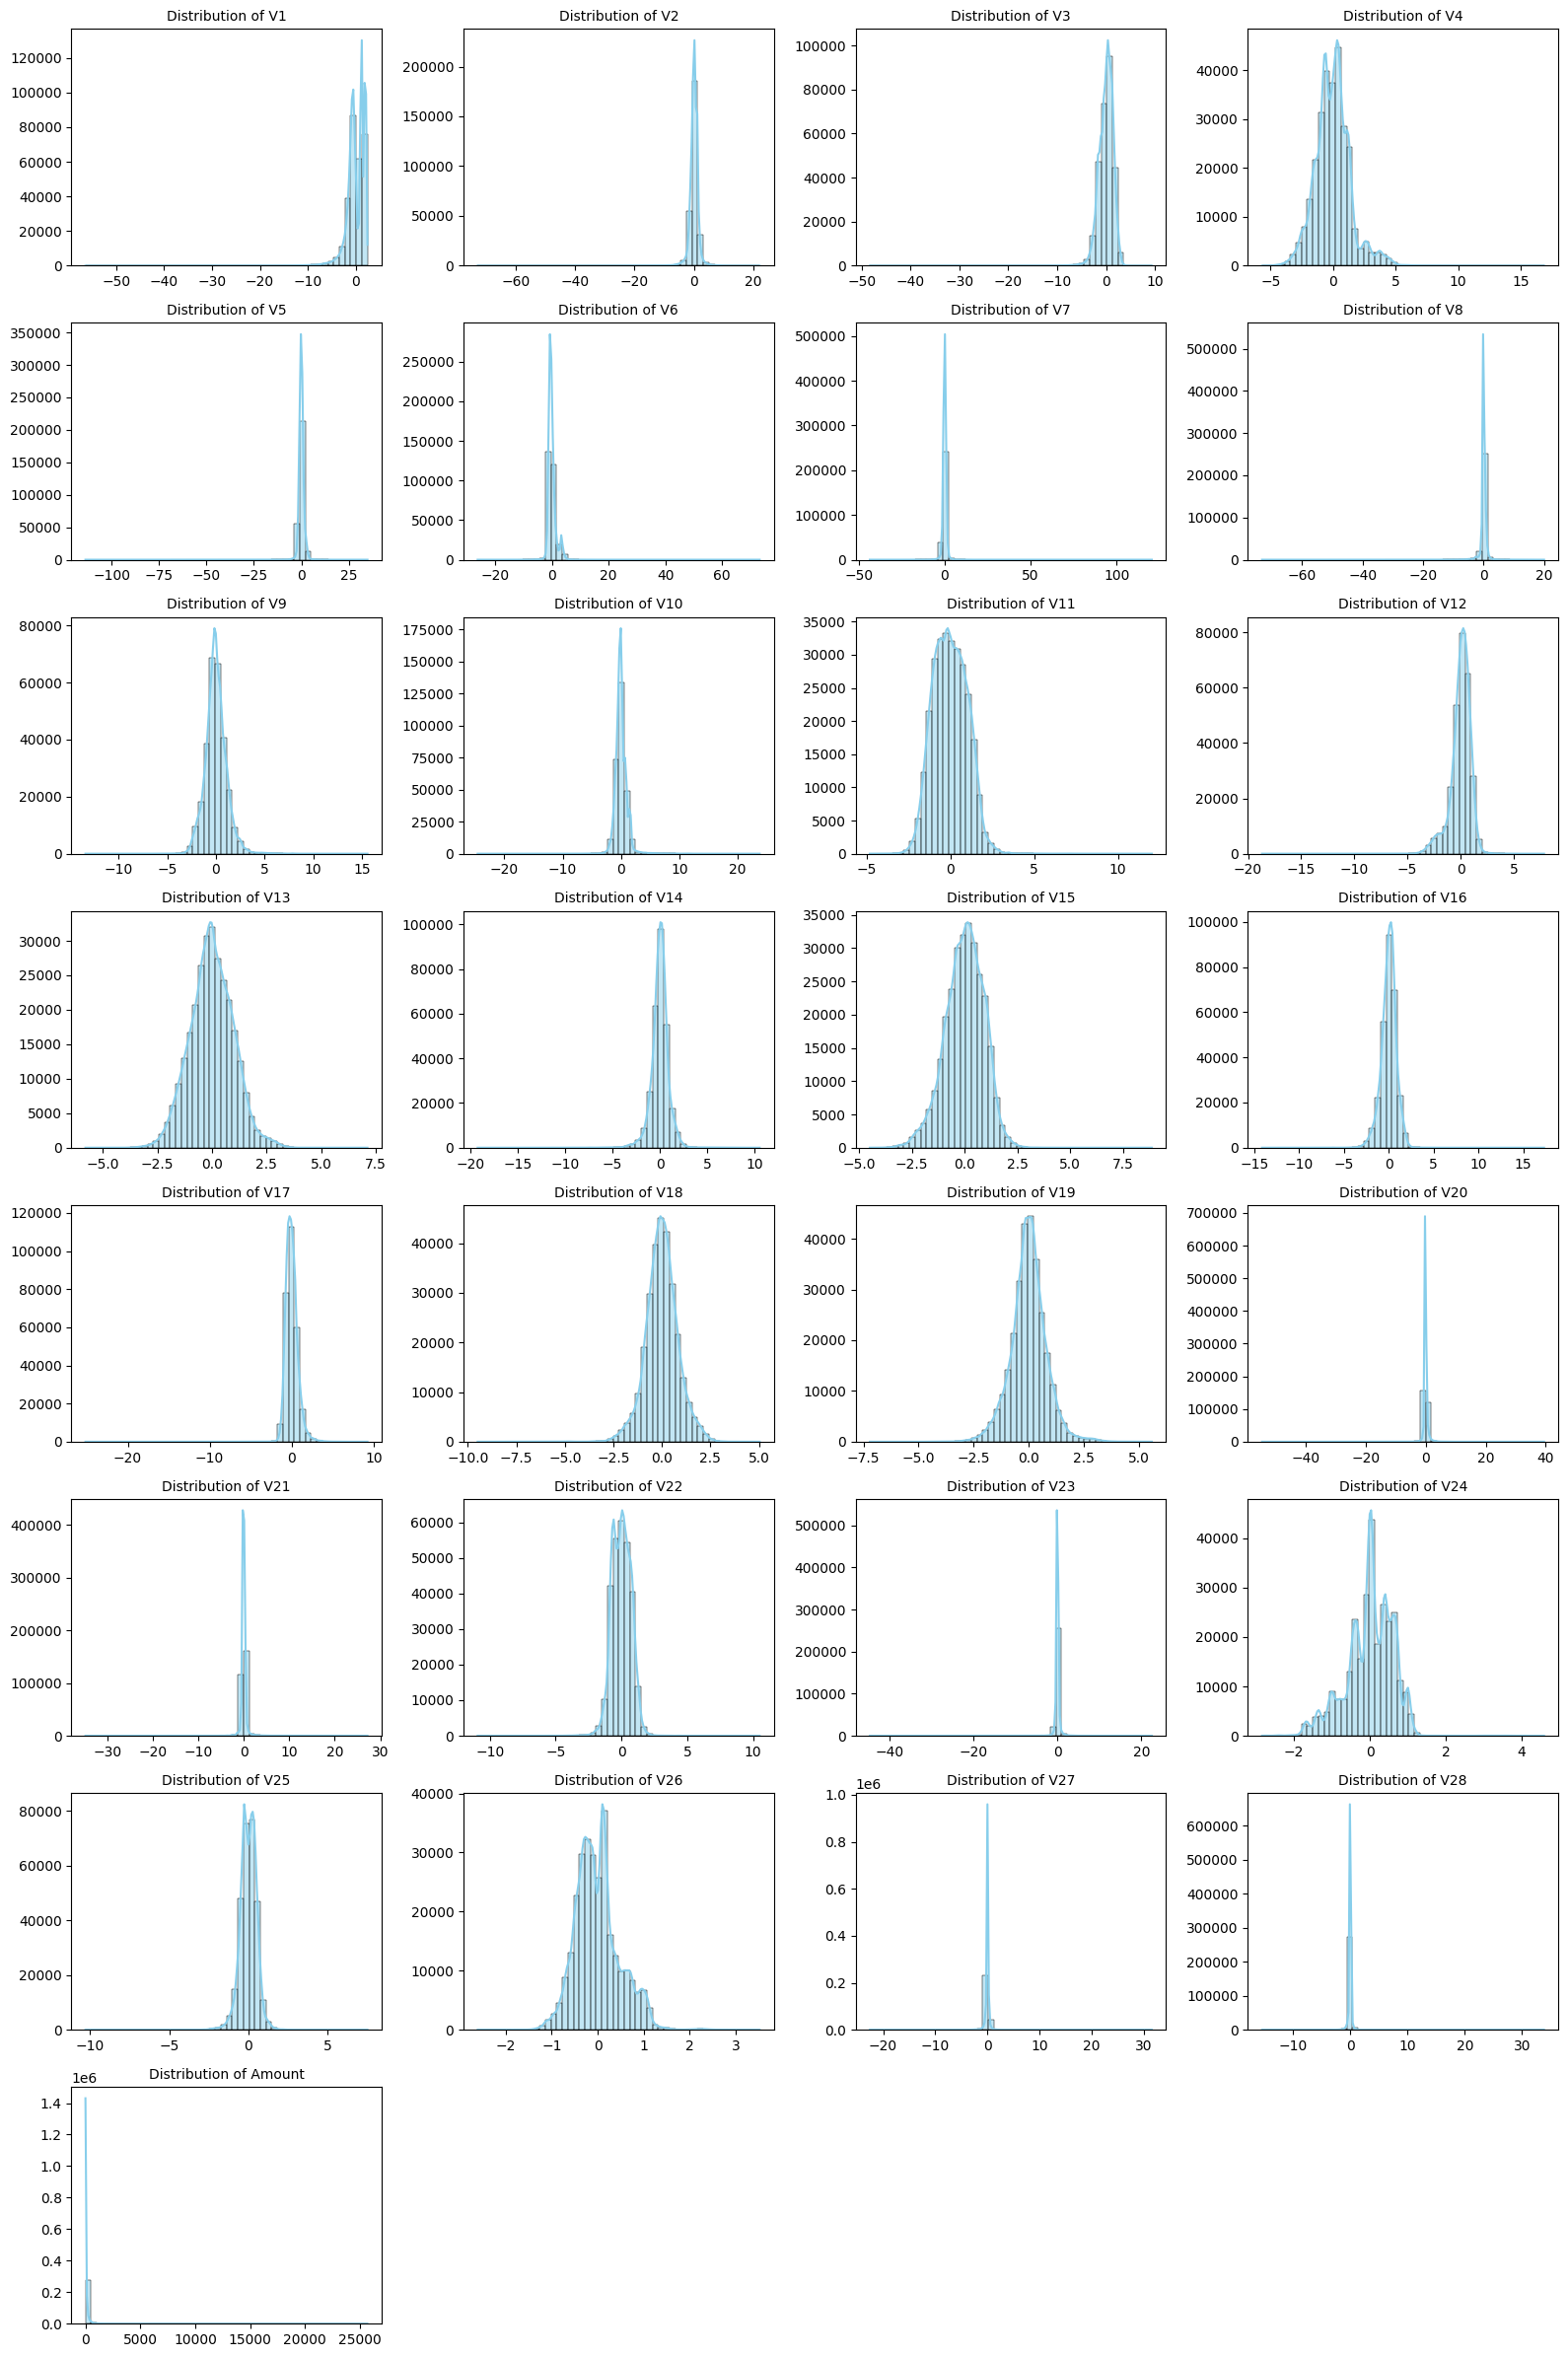

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all columns except 'Time' and 'Class'
features = df.drop(columns=['Time', 'Class']).columns

# Determine the number of rows and columns for the subplots grid
n_cols = 4  # Number of columns in the subplot grid
n_rows = (len(features) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[feature], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

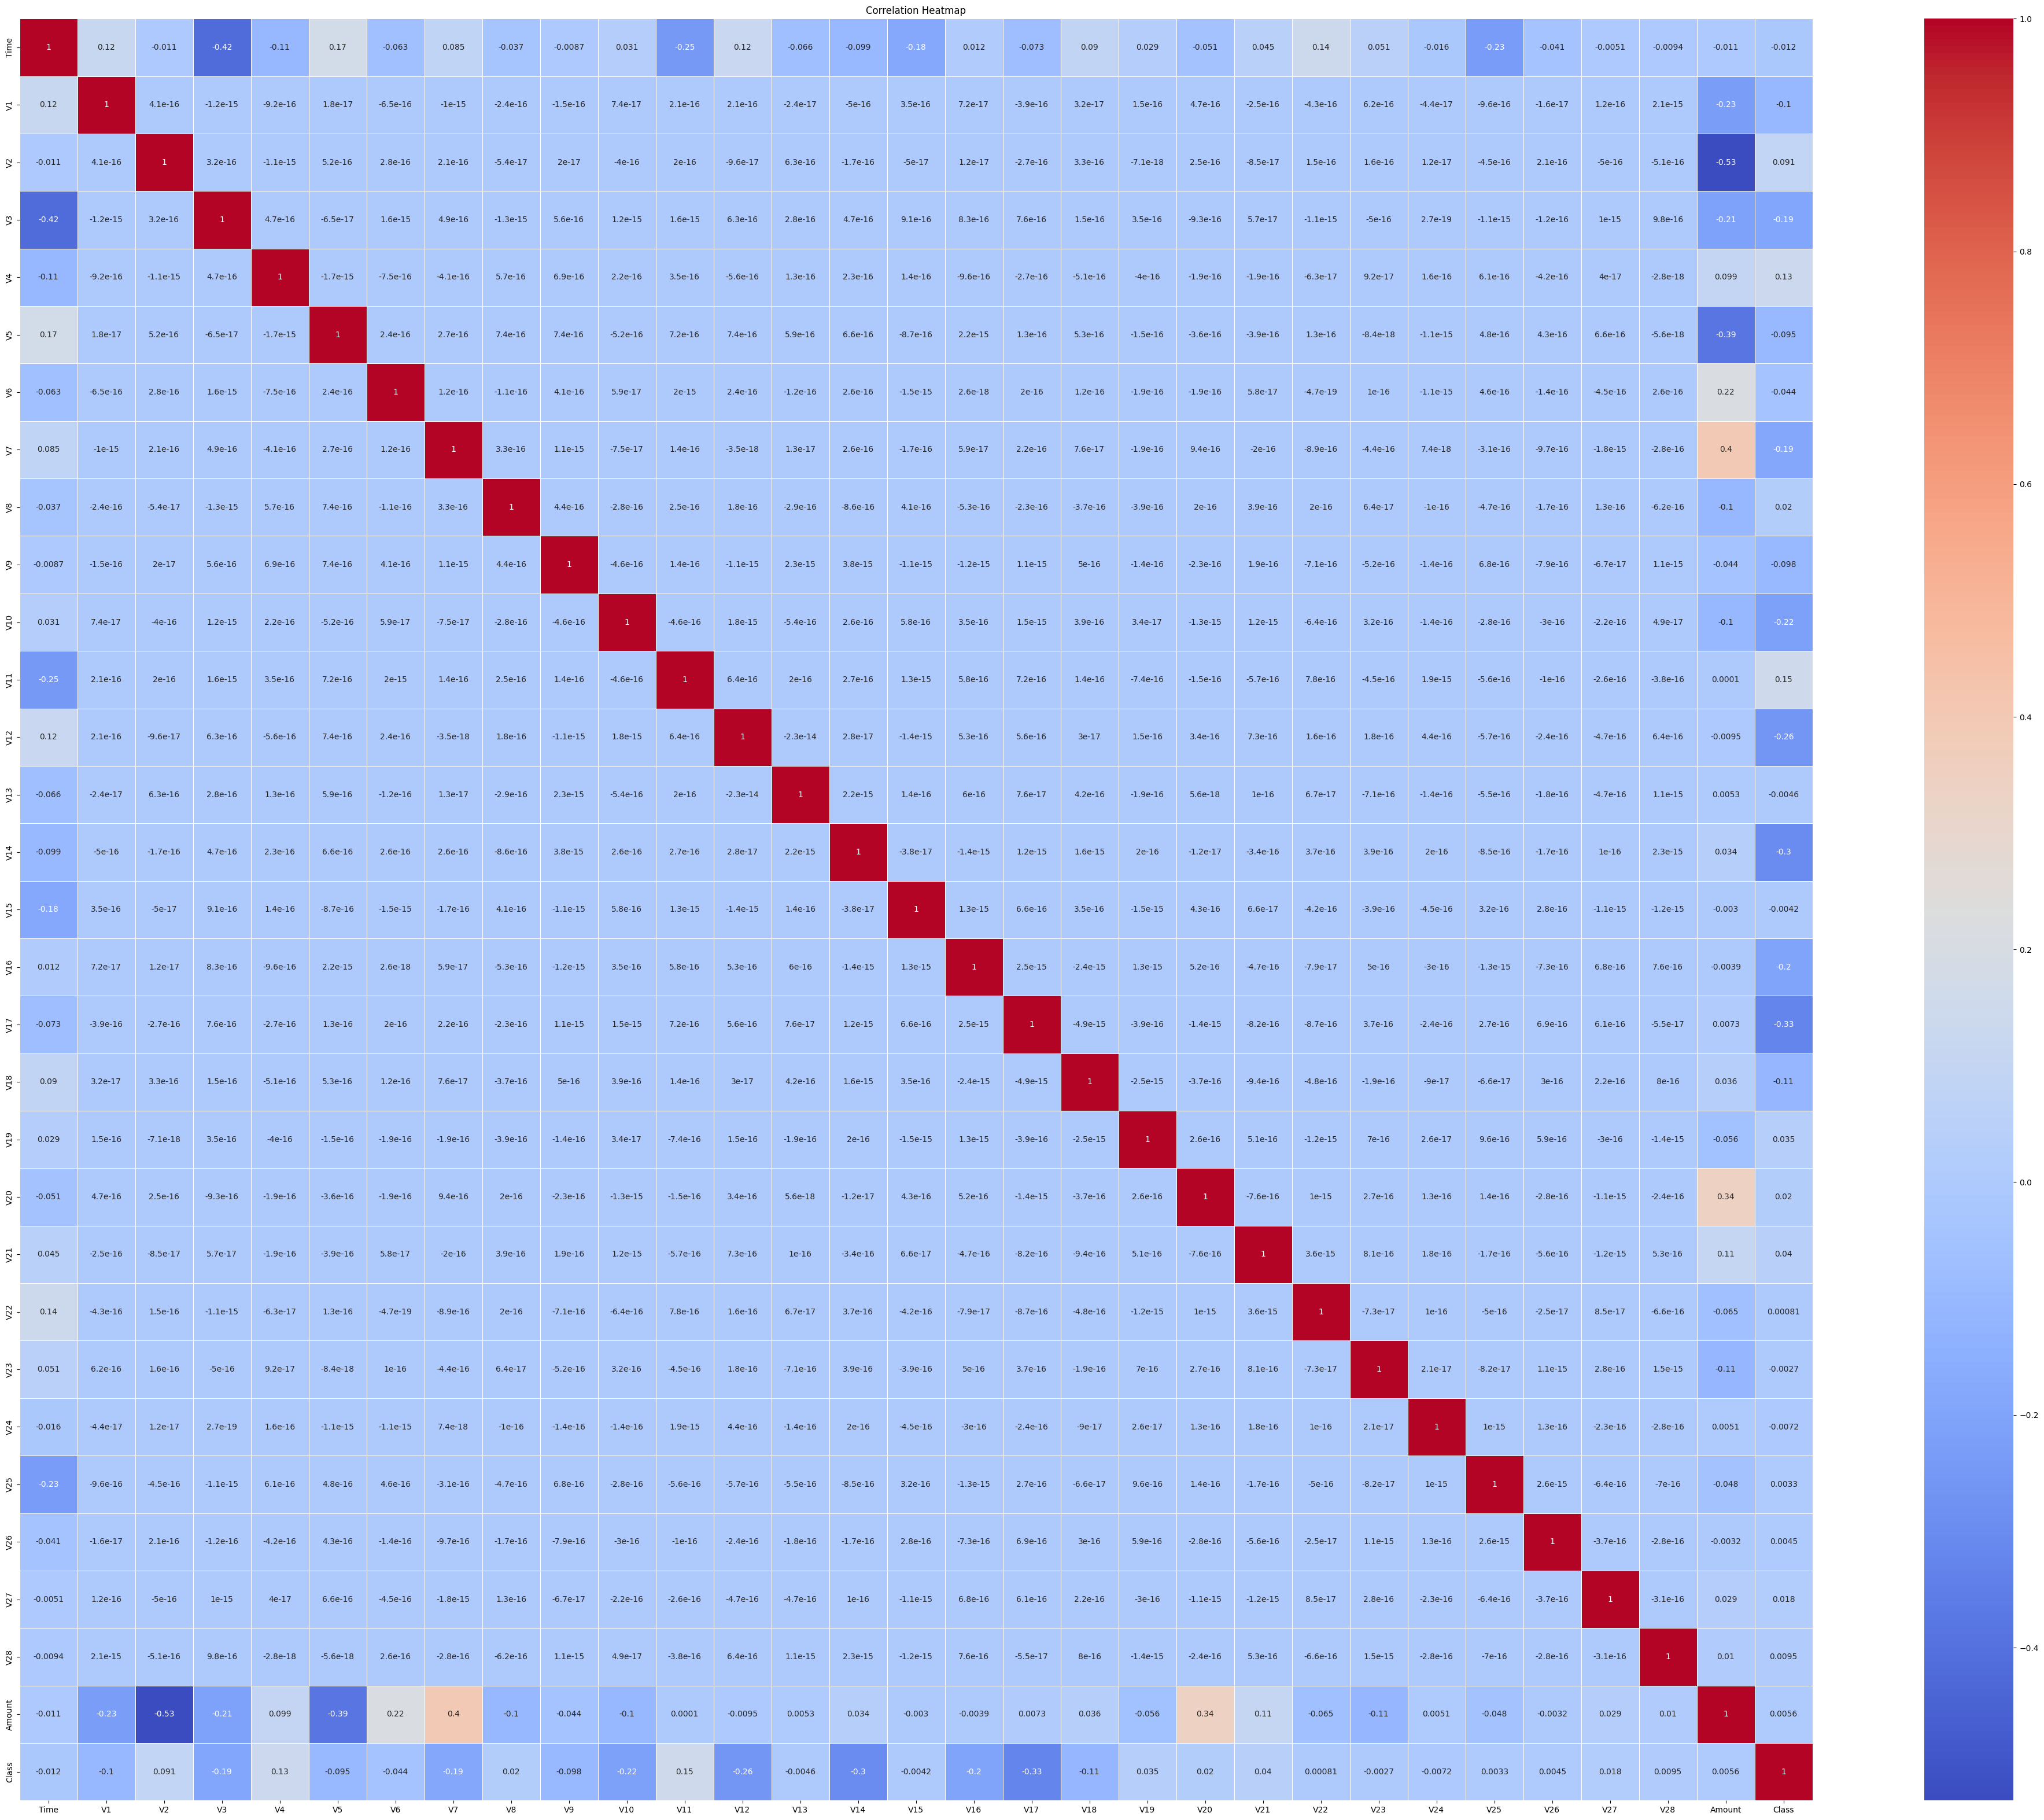

In [37]:
# print the correlation map
corr_matrix = df.corr()
#increase the dimensions or scale of heat map
plt.figure(figsize=(50, 40))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()





In [38]:
V_columns = [col for col in df.columns if col.startswith('V')]
df[V_columns] = scaler.fit_transform(df[V_columns])

In [39]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -0.694242 -0.044075  1.672773  0.973366 -0.245117  0.347068  0.193679   
1   0.0  0.608496  0.161176  0.109797  0.316523  0.043483 -0.061820 -0.063700   
2   1.0 -0.693500 -0.811578  1.169468  0.268231 -0.364572  1.351454  0.639776   
3   1.0 -0.493325 -0.112169  1.182516 -0.609727 -0.007469  0.936150  0.192071   
4   2.0 -0.591330  0.531541  1.021412  0.284655 -0.295015  0.071999  0.479302   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.082637  0.331128  ... -0.024923  0.382854 -0.176911  0.110507  0.246585   
1  0.071253 -0.232494  ... -0.307377 -0.880077  0.162201 -0.561131  0.320694   
2  0.207373 -1.378675  ...  0.337632  1.063358  1.456320 -1.138092 -0.628537   
3  0.316018 -1.262503  ... -0.147443  0.007267 -0.304777 -1.941027  1.241904   
4 -0.226510  0.744326  ... -0.012839  1.100011 -0.220123  0.233250 -0.395202   

        V26       V27       V28 

In [40]:
from sklearn.decomposition import PCA
import numpy as np

In [41]:
# Select the columns for PCA (all 'V' columns)
pca_features = [f'V{i}' for i in range(1, 29)]
X_pca = df[pca_features]

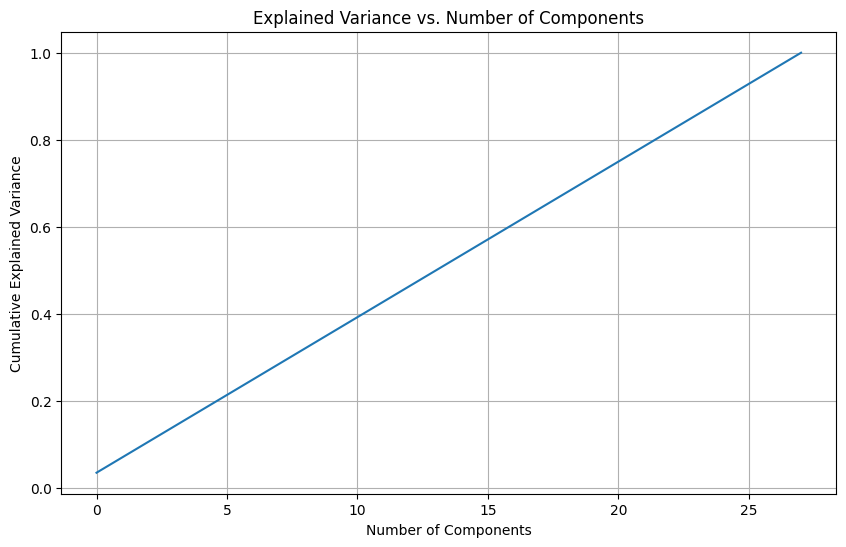

In [42]:
# Apply PCA
pca = PCA(n_components=None) # Start with all components to evaluate explained variance
pca.fit(X_pca)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

In [43]:
n_components_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components explaining at least 95% variance: {n_components_95}")

pca_final = PCA(n_components=n_components_95)
X_pca_transformed = pca_final.fit_transform(X_pca)

Number of components explaining at least 95% variance: 27


In [44]:
pca_df = pd.DataFrame(X_pca_transformed, columns=[f'PC_{i+1}' for i in range(n_components_95)])

# Drop original 'V' columns and concatenate new PCA features
df = df.drop(columns=pca_features)
df = pd.concat([df.reset_index(drop=True), pca_df], axis=1)

In [45]:
print(df.head())

   Time  Amount  Class      PC_1      PC_2      PC_3      PC_4      PC_5  \
0   0.0  149.62      0  0.239560  0.247004  0.011104 -0.514100 -0.243060   
1   0.0    2.69      0  0.379424 -0.037057 -0.736361 -0.417312 -0.347236   
2   1.0  378.66      0 -0.397258  1.497825  0.558487 -0.512142 -2.119790   
3   1.0  123.50      0 -0.275671  2.819668 -0.604493  0.841806 -0.282601   
4   2.0   69.99      0 -0.508971  0.064410  0.823906  0.010314  0.472303   

       PC_6      PC_7  ...     PC_18     PC_19     PC_20     PC_21     PC_22  \
0 -0.492609  0.655189  ... -0.360838 -0.172664 -0.408122 -0.257829  0.156291   
1  0.010453  0.866520  ...  0.381557  0.080567  1.046632 -0.231225 -0.223395   
2 -1.497771  0.781594  ... -0.966553 -1.451569 -1.261808 -1.803186  1.012033   
3 -0.413242 -1.180246  ... -0.435472 -0.065330 -0.156498 -0.274153  0.945462   
4  0.131741 -0.278781  ... -0.650616 -0.641287 -0.255763  0.749690 -0.225443   

      PC_23     PC_24     PC_25     PC_26     PC_27  
0  0.168

In [46]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [47]:
# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split data into training and test sets (optional, but good practice for final evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced') # 'liblinear' for small datasets, 'balanced' to handle imbalance

# Set up K-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(log_reg_model, X_train, y_train, cv=kf, scoring='accuracy')

print(f"Cross-validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

Cross-validation Accuracy Scores: [0.97656301 0.97715552 0.97430271 0.97364436 0.97555356]
Mean CV Accuracy: 0.9754
Standard Deviation of CV Accuracy: 0.0013


The cross-validation scores indicate the model's performance consistency across different folds. Now, let's train the model on the full training data and evaluate it on the hold-out test set.

In [49]:
# Train the model on the entire training set
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- Model Evaluation on Test Set ---
Accuracy: 0.9757

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Confusion Matrix:
[[55486  1378]
 [    8    90]]


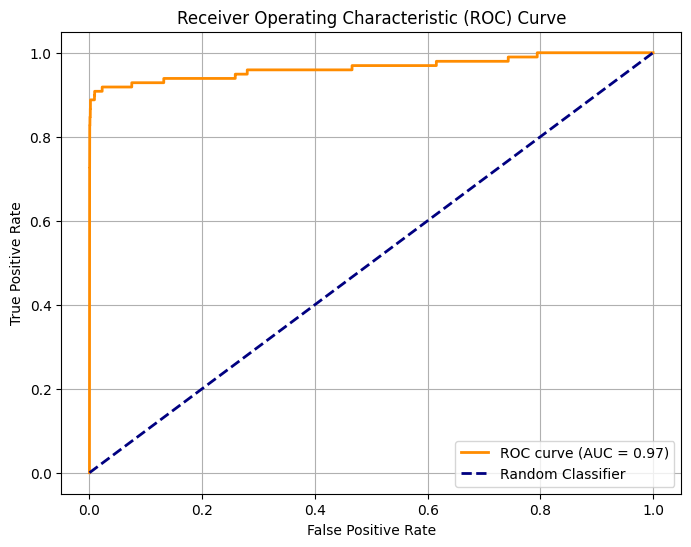

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()